<a href="https://colab.research.google.com/github/entropy-om/entheai/blob/rahul-phi-work/Rahul_rangarao_phi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install torch unsloth transformers datasets

In [2]:
!pip install peft bitsandbytes trl accelerate

In [ ]:
# Install a font that supports a wide range of Unicode characters (e.g., WenQuanYi Zen Hei CJK font)
!sudo apt-get install -y fonts-wqy-zenhei

# Clear matplotlib's font cache
import matplotlib.font_manager as fm
fm._load_fontmanager(try_read_cache=False)

## Local Inference on GPU
Model page: https://huggingface.co/microsoft/Phi-4-mini-instruct

What im trying to do:

In [24]:
from transformers import pipeline
from torch import nn
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
tokenizer = AutoTokenizer.from_pretrained("microsoft/Phi-4-mini-instruct")
model = AutoModelForCausalLM.from_pretrained(
    "microsoft/Phi-4-mini-instruct",
    torch_dtype="auto",       # bf16 → ~7.7 GB instead of ~15 GB
    device_map="auto",        # puts it on the GPU
)

This model config has set a `rope_parameters['original_max_position_embeddings']` field, to be used together with `max_position_embeddings` to determine a scaling factor. Please set the `factor` field of `rope_parameters`with this ratio instead -- we recommend the use of this field over `original_max_position_embeddings`, as it is compatible with most model architectures.


Loading weights:   0%|          | 0/194 [00:00<?, ?it/s]

In [6]:
print(model.lm_head)  # Linear(in_features=hidden_size, out_features=vocab_size, bias=False)

# Freeze the backbone — only train the new head
for param in model.model.parameters():
    param.requires_grad = False

hidden_size = model.config.hidden_size
vocab_size = model.config.vocab_size

Linear(in_features=3072, out_features=200064, bias=False)


In [7]:
# Example: replace with a deeper head instead of a single linear projection
class CustomLMHead(nn.Module):
    def __init__(self, hidden_size, vocab_size):
        super().__init__()
        self.proj1 = nn.Linear(hidden_size, hidden_size)
        self.act = nn.GELU()
        self.norm = nn.LayerNorm(hidden_size)
        self.proj2 = nn.Linear(hidden_size, vocab_size, bias=False)

    def forward(self, hidden_states):
        x = self.act(self.proj1(hidden_states))
        x = self.norm(x)
        return self.proj2(x)

model.lm_head = CustomLMHead(hidden_size, vocab_size).to(model.device, dtype=torch.bfloat16)

In [38]:
def generate_with_custom_sampling(model, tokenizer, prompt, max_new_tokens=50,
                                    temperature=0.8, top_k=42, top_p=0.8,
                                    repetition_penalty=1.1):
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    generated = inputs["input_ids"]
    step_probs = [] # To store the probability of the chosen token at each step

    for _ in range(max_new_tokens):
        with torch.no_grad():
            outputs = model(generated)
            logits = outputs.logits[:, -1, :]

        logits = logits / temperature

        for token_id in set(generated[0].tolist()):
            logits[0, token_id] /= repetition_penalty

        top_k_vals, top_k_idx = torch.topk(logits, top_k)
        filtered = torch.full_like(logits, float("-inf"))
        filtered.scatter_(1, top_k_idx, top_k_vals)

        probs = torch.softmax(filtered, dim=-1)
        next_token = torch.multinomial(probs, num_samples=1)

        # Capture the probability of the token that was actually picked
        actual_prob = probs[0, next_token.item()].item()
        step_probs.append(actual_prob)

        generated = torch.cat([generated, next_token], dim=1)
        if next_token.item() == tokenizer.eos_token_id:
            break

    return tokenizer.decode(generated[0], skip_special_tokens=False), probs, generated, step_probs

In [39]:

messages = [
      {"role": "user", "content": "Who are you? Who am I?"},
  ]

inputs = tokenizer.apply_chat_template(
      messages,
      add_generation_prompt=True,
      tokenize=True,
      return_dict=True,
      return_tensors="pt",
  ).to(model.device)

In [40]:
outputs = model.generate(**inputs, max_new_tokens=40)
print(tokenizer.decode(outputs[0][inputs["input_ids"].shape[-1]:], skip_special_tokens=True))

 cozinha पहचानtersíf advisecharacters яйtersłośćarlu advise पहचान/Event पहचान/Event/Event/Event cast पहचान/Event castLjavagetti पहचान/Event Planet cast Planet cast cast cast cast cast cast cast cast cast cast cast cast


It is definitely gibberish, It needs to be trained on "Rahul"

In [62]:
all_data_distri, last_step_probs, generated, token_probs = generate_with_custom_sampling(model, tokenizer, prompt=messages[0]['content'])

# Prepare data for DataFrame
prompt_len = tokenizer(messages[0]['content'], return_tensors="pt")["input_ids"].shape[1]
gen_tokens = generated[0][prompt_len:]

data = []
for i, (t_id, p) in enumerate(zip(gen_tokens, token_probs)):
    data.append({
        'position': i,
        'token_id': t_id.item(),
        'token_text': tokenizer.decode([t_id]),
        'probability': p
    })

df_results = pd.DataFrame(data)
display(df_results)

,position,token_id,token_text,probability
0,0,131670,دهید,0.021729
1,1,72350,одним,0.026367
2,2,189299,Тай,0.019531
3,3,172928,jährlich,0.020874
4,4,35527,381,0.028687
5,5,38447,्टर,0.034912
6,6,61561,_ELEMENT,0.019897
7,7,38447,्टर,0.023438
8,8,151344,lágrimas,0.026611
9,9,41424,ӡа,0.022339


In [75]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df_results)

https://docs.google.com/spreadsheets/d/1HeHDRXEBX4FclCAaThLzwSz54HiGGF7ThEq9E_J_cAg/edit#gid=0


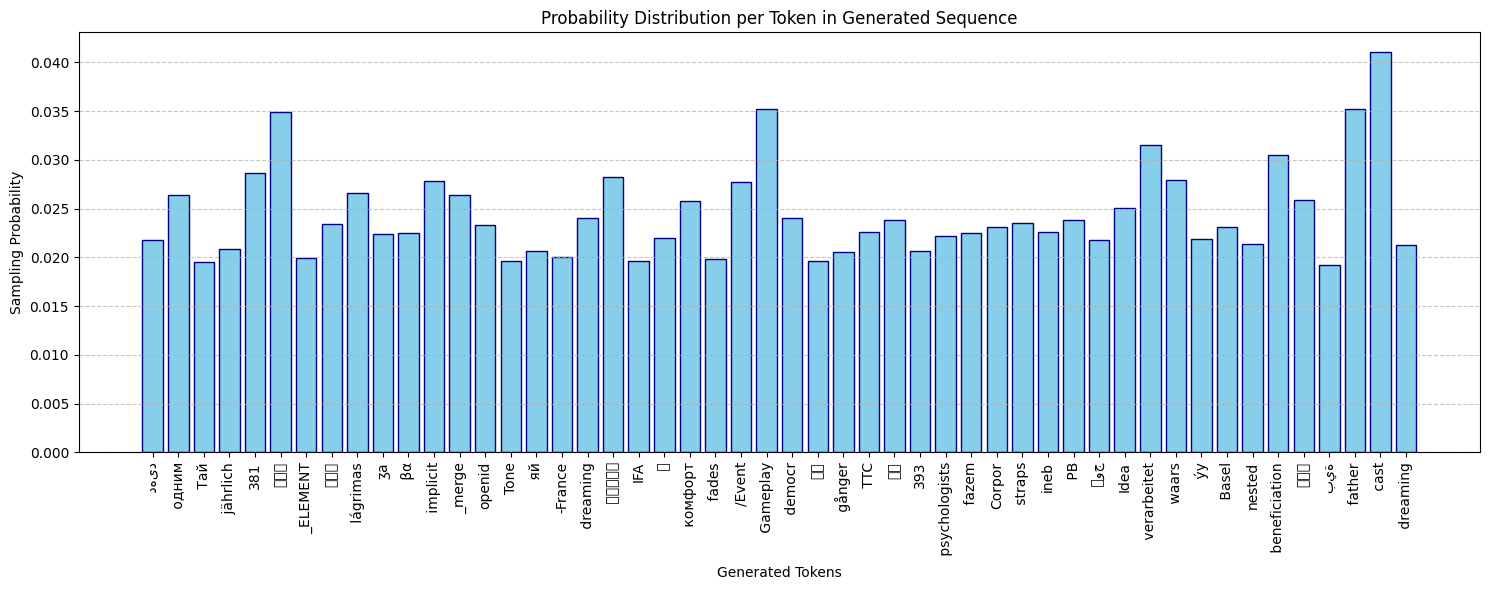

In [73]:
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module='matplotlib.font_manager')

plt.figure(figsize=(15, 6))
plt.bar(df_results['position'], df_results['probability'], color='skyblue', edgecolor='navy')
plt.xticks(df_results['position'], df_results['token_text'], rotation=90)
plt.xlabel('Generated Tokens')
plt.ylabel('Sampling Probability')
plt.title('Probability Distribution per Token in Generated Sequence')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [64]:
all_data_distri

'Who are you? Who am I? دهید одним Тай jährlich381्टर_ELEMENT्टर lágrimasӡа βα implicit_mergeopenidTone яй-France dreaming पहचानIFA 写 комфорт fades/Event Gameplay democr北京 gånger TTC吉林393 psychologists fazemCorpor strapsineb PB ہوجIdea verarbeitet waars ýy Baselnested beneficiationの場合بية father cast dreaming'

In [65]:
len(gen_tokens)==len(token_probs)

True

In [71]:
print(last_step_probs[last_step_probs > 0])

tensor([0.0305, 0.0210, 0.0233, 0.0206, 0.0229, 0.0233, 0.0300, 0.0220, 0.0287,
        0.0237, 0.0216, 0.0206, 0.0210, 0.0216, 0.0269, 0.0216, 0.0245, 0.0273,
        0.0212, 0.0229, 0.0242, 0.0229, 0.0261, 0.0223, 0.0237, 0.0210, 0.0261,
        0.0273, 0.0216, 0.0245, 0.0233, 0.0242, 0.0256, 0.0245, 0.0282, 0.0216,
        0.0220, 0.0277, 0.0216, 0.0233, 0.0216, 0.0210], device='cuda:0',
       dtype=torch.bfloat16)


In [74]:
last_step_probs[last_step_probs>0]

tensor([0.0305, 0.0210, 0.0233, 0.0206, 0.0229, 0.0233, 0.0300, 0.0220, 0.0287,
        0.0237, 0.0216, 0.0206, 0.0210, 0.0216, 0.0269, 0.0216, 0.0245, 0.0273,
        0.0212, 0.0229, 0.0242, 0.0229, 0.0261, 0.0223, 0.0237, 0.0210, 0.0261,
        0.0273, 0.0216, 0.0245, 0.0233, 0.0242, 0.0256, 0.0245, 0.0282, 0.0216,
        0.0220, 0.0277, 0.0216, 0.0233, 0.0216, 0.0210], device='cuda:0',
       dtype=torch.bfloat16)